In [1]:
import numpy as np
import matplotlib.pyplot as plt
from constrained_remez_qsp_fitter import ConstrainedRemezQSPFitter, evaluate_from_coeffs, make_evaluator, visualize_fit
from max_magnitude_from_result import max_magnitude_from_result
from pprint import pprint
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt

BLUE = "#00274C"
MAIZE = "#FFCB05"
LIGHT_GRAY = "#D9D9D9"

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

# Tune Codes for Plotting

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional


def visualize_error_stack(
    fitter,
    results: List[Dict[str, Any]],
    which: str = "scaled",
    n_plot: int = 5000,
    x_space: bool = False,
    figsize_per_row: float = 2.2,
    show_legend: bool = True,
    line_color: str = BLUE,
    accent_color: str = MAIZE,
    fit_region_color: str = LIGHT_GRAY,
    fit_region_alpha: float = 0.28,
    linewidth: float = 1.0,
    logy: bool = False,
) -> None:
    """
    Plot stacked error curves for a list of fitting results.

    Parameters
    ----------
    fitter :
        Fitter object with attributes/methods:
        - domain
        - omega_fit
        - target(w)
        - evaluate(coeffs, w, ks=ks)

    results : list of dict
        Each entry should have the format:
        {
            "degree": int,
            "ks": ...,
            "raw": {"coeffs": ..., "Delta": ..., "metrics": ...},
            "scaled": {"coeffs": ..., "Delta": ..., "metrics": ...},
        }

    which : {"scaled", "raw"}
        Choose which result block to visualize.

    n_plot : int
        Number of points used for plotting.

    x_space : bool
        If True, plot against x = cos(omega). The y-values are unchanged.

    figsize_per_row : float
        Height of each subplot row.

    show_legend : bool
        Whether to display a legend on each subplot.

    line_color : str
        Color of the error curve.

    accent_color : str
        Reserved accent color for future extensions/highlights.

    fit_region_color : str
        Background color used for Omega_fit.

    fit_region_alpha : float
        Transparency of the Omega_fit shaded region.

    linewidth : float
        Width of the error curve.

    logy : bool
        If True, use logarithmic scale on the y-axis.
    """
    if len(results) == 0:
        raise ValueError("results must be a non-empty list.")

    if which not in ("scaled", "raw"):
        raise ValueError("which must be either 'scaled' or 'raw'.")

    # Build plotting grid in omega-space
    w = np.linspace(fitter.domain[0], fitter.domain[1], n_plot, endpoint=True)
    g = fitter.actual_target(w)

    # Choose x-axis representation
    xvals = np.cos(w) if x_space else (w / np.pi)

    nrows = len(results)
    fig, axes = plt.subplots(
        nrows,
        1,
        figsize=(8, max(2.0, figsize_per_row * nrows)),
        sharex=True
    )

    if nrows == 1:
        axes = [axes]

    for ax, result in zip(axes, results):
        degree = result["degree"]
        ks = result["ks"]
        coeffs = result[which]["coeffs"]

        # Evaluate approximation and compute pointwise absolute error
        H = fitter.evaluate(coeffs, w, ks=ks)
        # err = np.abs(H - g)
        err = H - g

        # Keep error only on Omega_fit; mask everything else
        err_masked = np.full_like(err, np.nan, dtype=float)
        for a0, b0 in fitter.omega_fit:
            mask = (w >= a0) & (w <= b0)
            err_masked[mask] = err[mask]

        # Shade Omega_fit in the background
        for k, (a0, b0) in enumerate(fitter.omega_fit):
            if x_space:
                left = np.cos(b0)
                right = np.cos(a0)
                ax.axvspan(
                    left,
                    right,
                    color=fit_region_color,
                    alpha=fit_region_alpha,
                    # label=r"$\Omega_{\mathrm{fit}}$" if (k == 0 and show_legend) else None,
                )
            else:
                ax.axvspan(
                    a0 / np.pi,
                    b0 / np.pi,
                    color=fit_region_color,
                    alpha=fit_region_alpha,
                    # label=r"$\Omega_{\mathrm{fit}}$" if (k == 0 and show_legend) else None,
                )

        # Plot the error curve
        # curve_label = (
        #     fr"$|h-g|$ on $x_{{\mathrm{{fit}}}}$ [{which}]"
        #     if x_space
        #     else fr"$|H-g|$ on $\omega_{{\mathrm{{fit}}}}$ [{which}]"
        # )
        ax.plot(
            xvals,
            err_masked,
            color=line_color,
            linewidth=linewidth,
            # label=curve_label,
        )

        # Set subplot title and labels
        ax.set_title(f"polynomial degree = {degree}")
        ax.set_ylabel("error")

        # if logy:
        #     ax.set_yscale("log")

        ax.grid(True, alpha=0.3)

        if show_legend:
            ax.legend()

    # Set the shared x-label on the last axis
    if x_space:
        axes[-1].set_xlabel(r"$x$")
    else:
        axes[-1].set_xlabel(r"$\omega/\pi$")

    plt.tight_layout()
    # plt.show()
    return plt.gcf()

In [4]:
def visualize_fit_grid(
    fitter_result_pairs,
    which: str = "scaled",
    n_plot: int = 5000,
    x_space: bool = False,
    row_titles=None,
    use_actual_target: bool = True,
    target_color: str = MAIZE,
    approx_color: str = BLUE,
    fit_region_color: str = LIGHT_GRAY,
    fit_region_alpha: float = 0.25,
    target_linestyle: str = ":",
    approx_linewidth: float = 1.0,
    error_linewidth: float = 1.0,
    figsize_per_row: float = 2,
    width: float = 10,
    show_legend: bool = False,
    logy_error: bool = False,
    y_lower_limit_is_zero: bool = False
):
    """
    Plot a stacked two-panel visualization for multiple (fitter, result) pairs.

    Each row corresponds to one pair:
        - top panel: target function and approximation polynomial
        - bottom panel: approximation error

    Parameters
    ----------
    fitter_result_pairs : list of tuple
        List of (fitter, result) pairs. Each result may come from a different fitter.

    which : {"raw", "scaled"}
        Which approximation block to plot.

    n_plot : int
        Number of plotting points for each row.

    x_space : bool
        If True, plot against x = cos(omega). Otherwise plot against omega / pi.

    row_titles : list of str or None
        Optional vertical titles shown on the left of each row.

    use_actual_target : bool
        If True, use fitter.actual_target when available; otherwise use fitter.target.

    target_color : str
        Color for the target curve.

    approx_color : str
        Color for the approximation curve and error curve.

    fit_region_color : str
        Background color for Omega_fit.

    fit_region_alpha : float
        Transparency of the Omega_fit shaded region.

    target_linestyle : str
        Line style for the target curve.

    approx_linewidth : float
        Line width for the approximation curve.

    error_linewidth : float
        Line width for the error curve.

    figsize_per_row : float
        Figure height allocated to each row.

    width : float
        Figure width.

    show_legend : bool
        Whether to show legends on each top/bottom panel.

    logy_error : bool
        If True, use log scale on the error panels.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes array with shape (n_rows, 2).
    """
    if len(fitter_result_pairs) == 0:
        raise ValueError("fitter_result_pairs must be a non-empty list.")

    if which not in ("raw", "scaled"):
        raise ValueError("which must be either 'raw' or 'scaled'.")

    n_rows = len(fitter_result_pairs)

    if row_titles is not None and len(row_titles) != n_rows:
        raise ValueError("row_titles must have the same length as fitter_result_pairs.")

    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(width, max(2.5, figsize_per_row * n_rows)),
        sharex="col",
        squeeze=False,
        gridspec_kw={"height_ratios": [1] * n_rows},
    )

    for i, (fitter, result) in enumerate(fitter_result_pairs):
        ax_top = axes[i, 0]
        ax_bot = axes[i, 1]

        ks = result["ks"]
        coeffs = result[which]["coeffs"]

        w = np.linspace(fitter.domain[0], fitter.domain[1], n_plot, endpoint=True)

        if use_actual_target and hasattr(fitter, "actual_target"):
            g = fitter.actual_target(w)
        else:
            g = fitter.target(w)

        H = fitter.evaluate(coeffs, w, ks=ks)
        err = H - g

        xvals = np.cos(w) if x_space else (w / np.pi)

        # Mask target and error outside Omega_fit
        g_masked = np.full_like(g, np.nan, dtype=float)
        err_masked = np.full_like(err, np.nan, dtype=float)

        for a0, b0 in fitter.omega_fit:
            mask = (w >= a0) & (w <= b0)
            g_masked[mask] = g[mask]
            err_masked[mask] = err[mask]

        # Shade Omega_fit on both panels
        for k, (a0, b0) in enumerate(fitter.omega_fit):
            if x_space:
                left, right = np.cos(b0), np.cos(a0)
            else:
                left, right = a0 / np.pi, b0 / np.pi

            ax_top.axvspan(
                left,
                right,
                color=fit_region_color,
                alpha=fit_region_alpha,
                # label=r"$\Omega_{\mathrm{fit}}$" if (show_legend and k == 0) else None,
            )
            ax_bot.axvspan(
                left,
                right,
                color=fit_region_color,
                alpha=fit_region_alpha,
                # label=r"$\Omega_{\mathrm{fit}}$" if (show_legend and k == 0) else None,
            )

        # Top panel: target and approximation

        ax_top.plot(
            xvals,
            H,
            color=approx_color,
            linewidth=approx_linewidth,
            label=f"{which} approximation",
        )
        ax_top.plot(
            xvals,
            g_masked,
            linestyle=target_linestyle,
            color=target_color,
            linewidth=2.0,
            label="target",
        )
        ax_top.axhline(1.0, linestyle="--", color="gray", linewidth=1.0, alpha=0.6)
        ax_top.axhline(
            -1.0 if not y_lower_limit_is_zero else 0.0, 
            linestyle="--", color="gray", linewidth=1.0, alpha=0.6
        )
        ax_top.set_ylabel("value")

        # Bottom panel: approximation error
        ax_bot.plot(
            xvals,
            err_masked,
            color=approx_color,
            linewidth=error_linewidth,
            label="approximation error",
        )
        ax_bot.set_ylabel("error")
        if logy_error:
            ax_bot.set_yscale("log")

        # Row title on the far left, vertical
        if row_titles is not None:
            ax_top.text(
                -0.22,
                0.5,
                row_titles[i],
                rotation=90,
                va="center",
                ha="center",
                transform=ax_top.transAxes,
            )

        if show_legend:
            ax_top.legend()
            ax_bot.legend()

    # Shared x labels only on last row
    if x_space:
        axes[-1, 0].set_xlabel(r"$x$")
        axes[-1, 1].set_xlabel(r"$x$")
    else:
        axes[-1, 0].set_xlabel(r"$\omega/\pi$")
        axes[-1, 1].set_xlabel(r"$\omega/\pi$")

    plt.tight_layout()
    return fig, axes

# Heaviside Example
$$g(x) = \left\{\begin{array}{ll} 1 & x < \mu - \delta \\ 0 & x > \mu + \delta  \end{array}\right.$$

We set $\mu = 0.5, \delta = 0.05$. Two subintervals in $\omega$-space
$$\mathcal{I}_1 = \arccos([0, (\mu - \delta)) = (\arccos(\mu - \delta), \pi/2] \qquad \mathcal{I}_0 = \arccos((\mu + \delta, 1]) = [0, \arccos(\mu + \delta))$$

## Experiments

In [5]:

deg_list = (
        (2 ** np.arange(start = 5, stop = 8.5, step = 0.5)) // 2 * 2
    ).astype(int)

print(deg_list)

err_on_fit = np.zeros(deg_list.shape, dtype = float)
result_fit = {}


mu = 0.5
delta = 0.05
zeta = 1e-7

endpt_I0 = np.arccos(mu + delta)
endpt_I1 = np.arccos(mu - delta)

omega_fit = [
    (0.0, endpt_I0),
    (endpt_I1, 0.5 * np.pi),
]

eps = 1e-4
omega_work = [
    (0.0, endpt_I0 - eps),
    (endpt_I1 + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return (
        0.0 * np.logical_and((w <= endpt_I0), (w >= 0))
        + 
        1.0 * np.logical_and((w >= endpt_I1), (w <= np.pi / 2))
        ).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
    actual_target=lambda w: target(w) / (1 - zeta)
)

for j in tqdm(range(deg_list.shape[0])):
    d = deg_list[j]
    result = fitter.fit(d=d)
    err_on_fit[j] = result["scaled"]["metrics"]["max_fit_error_on_fit"]
    result_fit[d] = result
    info_raw = max_magnitude_from_result(result, which="raw")
    info_scaled = max_magnitude_from_result(result, which="scaled")
    if info_scaled["max_abs"] > 1 + err_on_fit[j] / 100:
        print("Error", j, info_scaled["max_abs"])

    # print(info_raw["max_abs"], info_raw["argmax_abs"])
    # print(info_scaled["max_abs"], info_scaled["argmax_abs"])


[ 32  44  64  90 128 180 256]


100%|██████████| 7/7 [01:53<00:00, 16.16s/it]


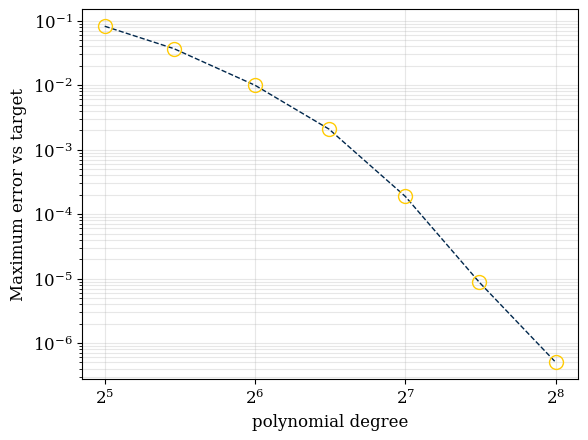

In [6]:
plt.plot(deg_list, err_on_fit, "--", c = BLUE, linewidth = 1)
plt.plot(deg_list, err_on_fit, linestyle = "None", marker = "o", markersize = 10, markerfacecolor = "None", markeredgecolor = MAIZE)
plt.xscale("log", base = 2)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("Maximum error vs target")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("Remez_threshold_projection.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

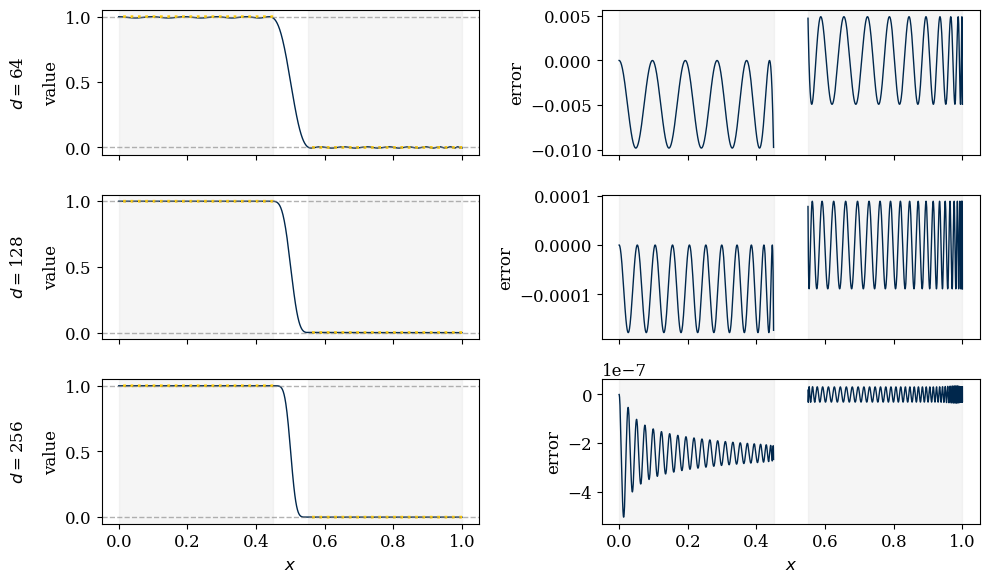

In [7]:
d_l_plt = [deg_list[-5], deg_list[-3], deg_list[-1]]
results_list = [result_fit[d] for d in d_l_plt]

fig, _ = visualize_fit_grid(
    [[fitter, res] for res in results_list],
    which = "scaled",
    x_space = True,
    row_titles=[r"$d = ${:d}".format(d) for d in d_l_plt],
    y_lower_limit_is_zero=True
    )
fig.savefig("Remez_threshold_projection_approx_and_error.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

# Linear System
$$g(x) = \frac{1}{2 \kappa x}, \frac{1}{2\kappa} \le x \le 1$$
Parameter is set to $\kappa = 5$

$\omega$-convention
$$\tilde{g}(\omega) = \frac{1}{2 \kappa \cos(\omega)}, 0 \le \omega \le \arccos(1/(2\kappa))$$
Derivative
$$\tilde{g}^\prime(\omega) = - \frac{\sin(\omega)}{2 \kappa \cos^2(\omega)}$$


## Experiment

In [3]:

deg_list = (
        (2 ** np.arange(start = 5, stop = 9.5, step = 0.5)) // 2 * 2 + 1
    ).astype(int)

print(deg_list)

err_on_fit = np.zeros(deg_list.shape, dtype = float)
result_fit = {}


kappa = 5
zeta = 1e-6

endpt = np.arccos(1 / (2 * kappa))

omega_fit = [
    (0.0, endpt),
]

def target(w):
    w = np.asarray(w)
    return 1 / (2 * kappa * np.cos(w)) * (1 - zeta)

def target_prime(w):
    return np.sin(w) / (2 * kappa * np.cos(w) ** 2) * (1 - zeta)

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
    actual_target=lambda w: target(w) / (1 - zeta)
)

for j in tqdm(range(deg_list.shape[0])):
    d = deg_list[j]
    result = fitter.fit(d=d)
    err_on_fit[j] = result["scaled"]["metrics"]["max_fit_error_on_fit"]
    result_fit[d] = result
    info_raw = max_magnitude_from_result(result, which="raw")
    info_scaled = max_magnitude_from_result(result, which="scaled")
    if info_scaled["max_abs"] > 1 + err_on_fit[j] / 100:
        print("Error", j, info_scaled["max_abs"])


[ 33  45  65  91 129 181 257 363 513]


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [02:35<00:00, 17.29s/it]


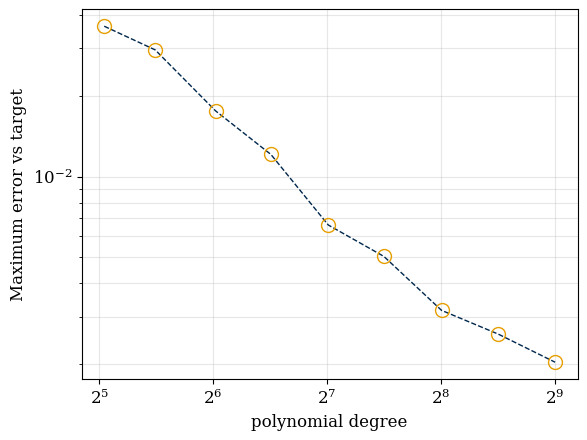

In [4]:
plt.plot(deg_list, err_on_fit, "--", c = BLUE, linewidth = 1)
plt.plot(deg_list, err_on_fit, linestyle = "None", marker = "o", markersize = 10, markerfacecolor = "None", markeredgecolor = MAIZE)
plt.xscale("log", base = 2)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("Maximum error vs target")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("Remez_linear_system.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

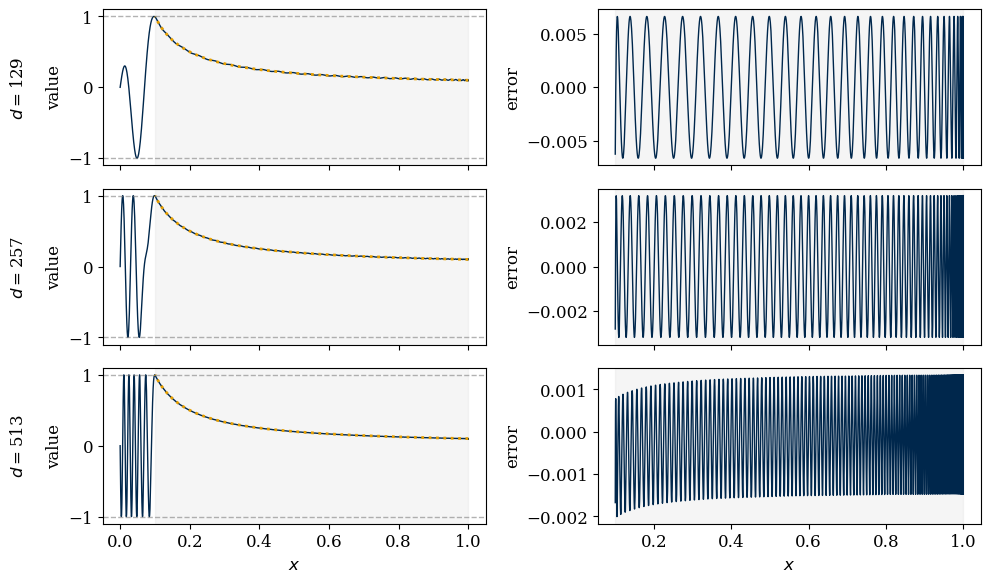

In [ ]:
d_l_plt = [deg_list[-5], deg_list[-3], deg_list[-1]]
results_list = [result_fit[d] for d in d_l_plt]

fig, _ = visualize_fit_grid(
    [[fitter, res] for res in results_list],
    which = "scaled",
    x_space = True,
    row_titles=[r"$d = ${:d}".format(d) for d in d_l_plt]
    )
fig.savefig("Remez_linear_system_error.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

# Amplitude Amplification
An odd function
$$g(x) = \frac{x}{\Gamma}, 0 \le x \le \Gamma$$
Parameter is set to $\Gamma = 0.2$

$\omega$-convention
$$\tilde{g}(\omega) = \frac{\cos(\omega)}{\Gamma}, \arccos(\Gamma) \le \omega \le \frac{\pi}{2}$$
Derivative
$$\tilde{g}^\prime(\omega) = - \frac{\sin(\omega)}{\Gamma}$$


## Sanity check

In [25]:
fit_res_pair = []
eps_list = []

{'degree': 301,
 'fit_interval_error_0': 0.0010334972915528873,
 'kind': 'raw',
 'max_abs_on_domain': 1.0000000000000029,
 'max_constraint_violation': 2.886579864025407e-15,
 'max_fit_error_on_fit': 0.0010334972915528873,
 'max_fit_error_on_work': 0.0007181881709577009,
 'num_coefficients': 151,
 'raw_max_magnitude': 1.0000000000000029,
 'ripple_amplitude': 0.0007181881709636068,
 'scaling_factor': 1.0,
 'work_interval_error_0': 0.0007181881709577009}

{'degree': 301,
 'fit_interval_error_0': 0.0010334972915557739,
 'kind': 'scaled',
 'max_abs_on_domain': 1.0,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.0010334972915557739,
 'max_fit_error_on_work': 0.0007181881709605875,
 'num_coefficients': 151,
 'raw_max_magnitude': 1.0000000000000029,
 'ripple_amplitude': 0.0007181881709636047,
 'scaling_factor': 1.0000000000000029,
 'work_interval_error_0': 0.0007181881709605875}


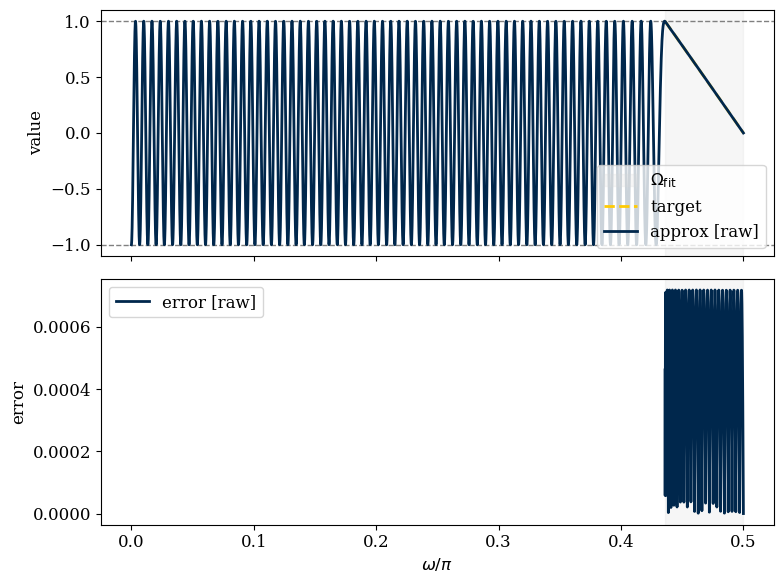

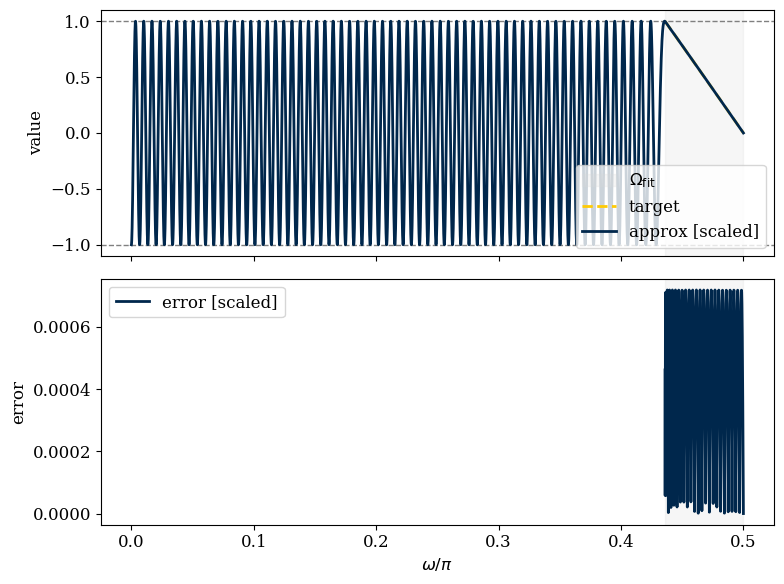

In [26]:
Gamma = 0.2
zeta = 0

d = 301

endpt = np.arccos(Gamma)

omega_fit = [
    (endpt, 0.5 * np.pi),
]

eps = 4e-2 / d
# eps = 2e-2
omega_work = [
    (endpt + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return np.cos(w) / Gamma * (1 - zeta)

def target_prime(w):
    return - np.sin(w) / Gamma * (1 - zeta)

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=d)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

fit_res_pair.append([fitter, result])
eps_list.append(eps)


{'degree': 151,
 'fit_interval_error_0': 0.0021312153455034233,
 'kind': 'raw',
 'max_abs_on_domain': 0.9999999999999989,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.0021312153455034233,
 'max_fit_error_on_work': 0.0017959993136588137,
 'num_coefficients': 76,
 'raw_max_magnitude': 0.9999999999999989,
 'ripple_amplitude': 0.001795999313659582,
 'scaling_factor': 1.0,
 'work_interval_error_0': 0.0017959993136588137}

{'degree': 151,
 'fit_interval_error_0': 0.0021312153455034233,
 'kind': 'scaled',
 'max_abs_on_domain': 0.9999999999999989,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.0021312153455034233,
 'max_fit_error_on_work': 0.0017959993136588137,
 'num_coefficients': 76,
 'raw_max_magnitude': 0.9999999999999989,
 'ripple_amplitude': 0.001795999313659582,
 'scaling_factor': 1.0,
 'work_interval_error_0': 0.0017959993136588137}


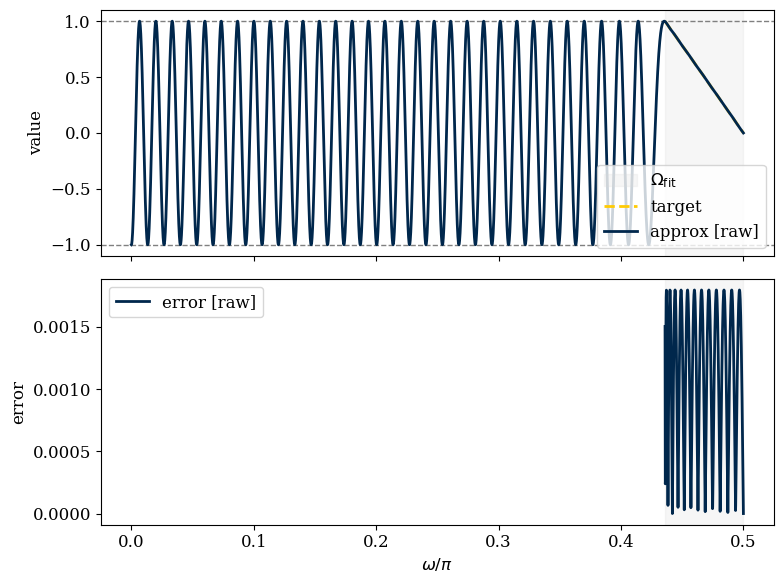

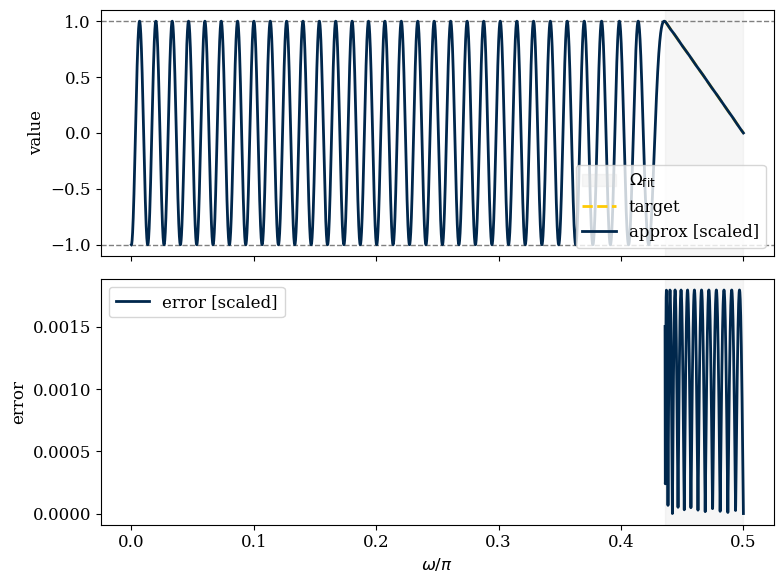

In [ ]:
Gamma = 0.2
zeta = 0

d = 151

endpt = np.arccos(Gamma)

omega_fit = [
    (endpt, 0.5 * np.pi),
]

eps = 4e-2 / 301
omega_work = [
    (endpt + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return np.cos(w) / Gamma * (1 - zeta)

def target_prime(w):
    return - np.sin(w) / Gamma * (1 - zeta)

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=d)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

fit_res_pair.append([fitter, result])
eps_list.append(eps)


{'degree': 75,
 'fit_interval_error_0': 0.004406190794813858,
 'kind': 'raw',
 'max_abs_on_domain': 1.000000000000002,
 'max_constraint_violation': 1.9984014443252818e-15,
 'max_fit_error_on_fit': 0.004406190794813858,
 'max_fit_error_on_work': 0.004060509715711036,
 'num_coefficients': 38,
 'raw_max_magnitude': 1.000000000000002,
 'ripple_amplitude': -0.0040605097157088346,
 'scaling_factor': 1.0,
 'work_interval_error_0': 0.004060509715711036}

{'degree': 75,
 'fit_interval_error_0': 0.004406190794815523,
 'kind': 'scaled',
 'max_abs_on_domain': 0.9999999999999999,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.004406190794815523,
 'max_fit_error_on_work': 0.004060509715713034,
 'num_coefficients': 38,
 'raw_max_magnitude': 1.000000000000002,
 'ripple_amplitude': -0.004060509715708827,
 'scaling_factor': 1.000000000000002,
 'work_interval_error_0': 0.004060509715713034}


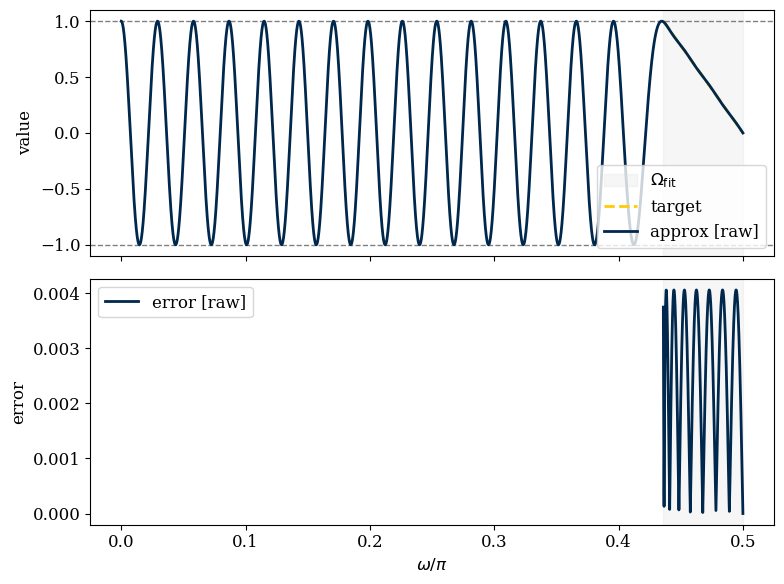

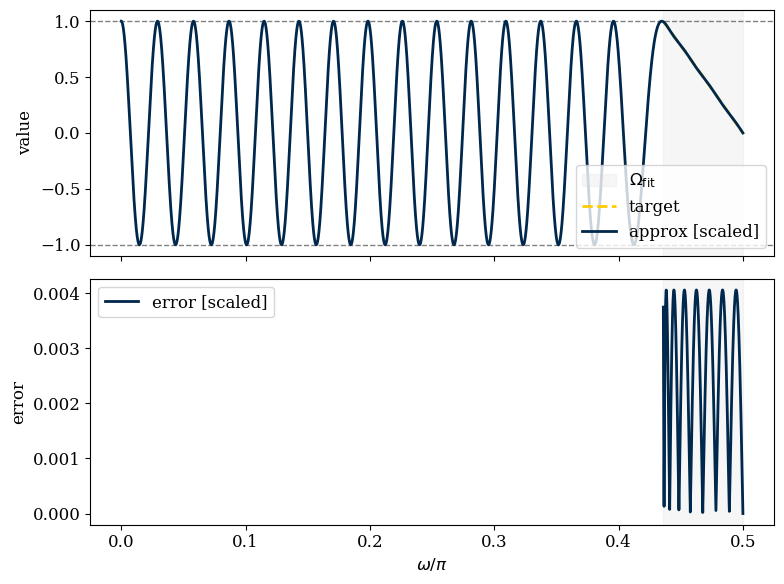

In [ ]:
Gamma = 0.2
zeta = 0

d = 75

endpt = np.arccos(Gamma)

omega_fit = [
    (endpt, 0.5 * np.pi),
]

eps = 4e-2 / 301
omega_work = [
    (endpt + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return np.cos(w) / Gamma * (1 - zeta)

def target_prime(w):
    return - np.sin(w) / Gamma * (1 - zeta)

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=d)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

fit_res_pair.append([fitter, result])
eps_list.append(eps)


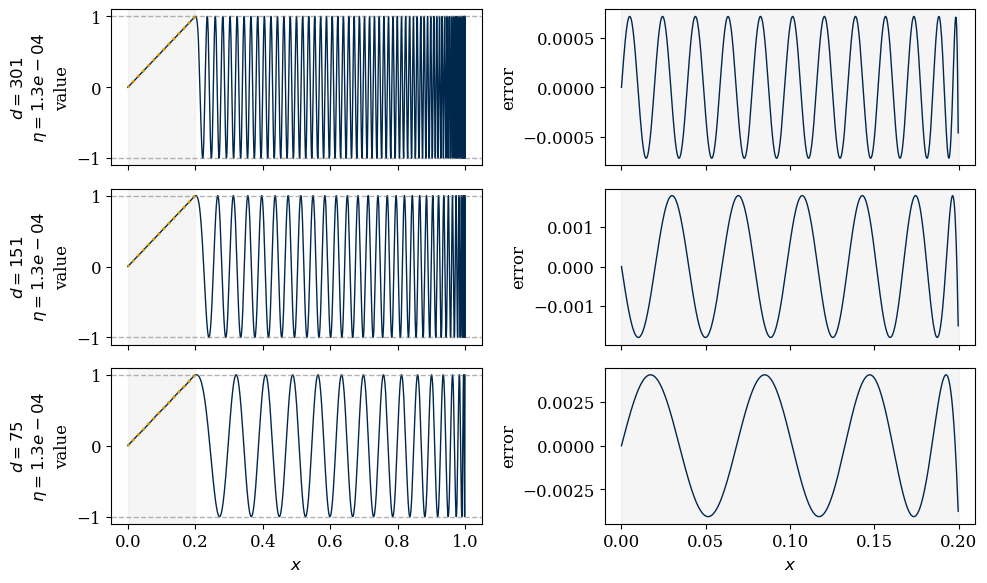

In [ ]:
d_l_plt = [301, 151, 75]
fig, _ = visualize_fit_grid(
    fit_res_pair,
    which = "scaled",
    x_space = True,
    row_titles = [
        "$d = {:d}$\n$\\eta = {:.1e}$".format(d, eps)
        for d, eps in zip(d_l_plt, eps_list)
    ]
    )
fig.savefig("Remez_amplitude_amplification_error.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

## Experiment

In [40]:

deg_list = (
        (2 ** np.arange(start = 5, stop = 8.5, step = 0.5)) // 2 * 2 + 1
    ).astype(int)

print(deg_list)

err_on_fit = np.zeros(deg_list.shape, dtype = float)
result_fit = {}


Gamma = 0.2
zeta = 0

endpt = np.arccos(Gamma)

omega_fit = [
    (endpt, 0.5 * np.pi),
]

eps = 4e-2 / 301
omega_work = [
    (endpt + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return np.cos(w) / Gamma * (1 - zeta)

def target_prime(w):
    return - np.sin(w) / Gamma * (1 - zeta)

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
    actual_target=lambda w: target(w) / (1 - zeta)
)


for j in tqdm(range(deg_list.shape[0])):
    d = deg_list[j]
    result = fitter.fit(d=d)
    err_on_fit[j] = result["scaled"]["metrics"]["max_fit_error_on_fit"]
    result_fit[d] = result
    info_raw = max_magnitude_from_result(result, which="raw")
    info_scaled = max_magnitude_from_result(result, which="scaled")
    if info_scaled["max_abs"] > 1 + err_on_fit[j] / 100:
        print("Error", j, info_scaled["max_abs"])


[ 33  45  65  91 129 181 257]


100%|██████████| 7/7 [05:23<00:00, 46.17s/it]


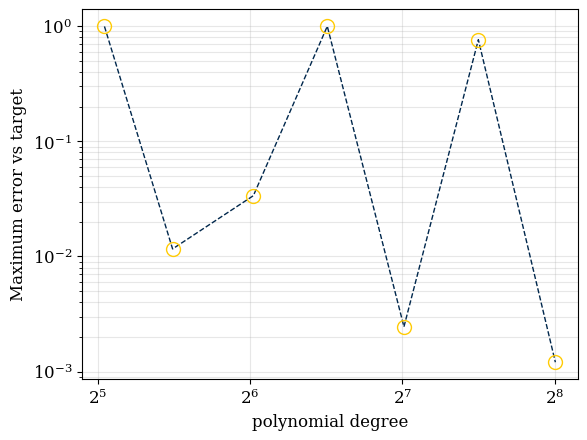

In [41]:
plt.plot(deg_list, err_on_fit, "--", c = BLUE, linewidth = 1)
plt.plot(deg_list, err_on_fit, linestyle = "None", marker = "o", markersize = 10, markerfacecolor = "None", markeredgecolor = MAIZE)
plt.xscale("log", base = 2)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("Maximum error vs target")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("Remez_amplitude_amplification.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)

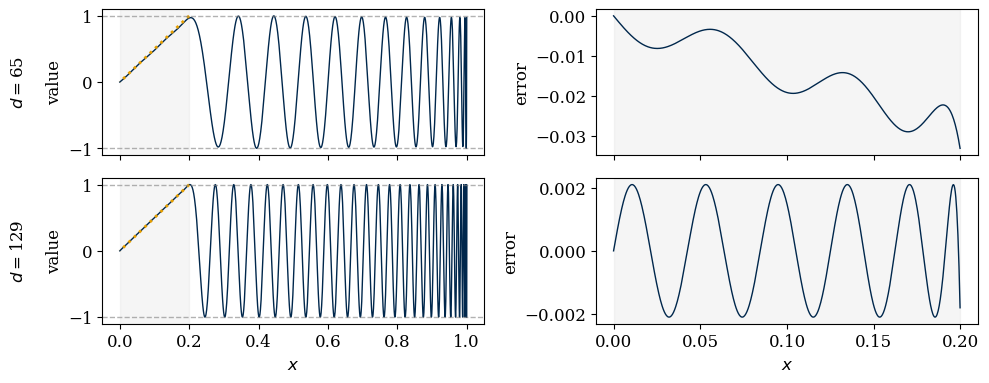

In [ ]:
d_l_plt = [deg_list[-5], deg_list[-3], deg_list[-2], deg_list[-1]]
fig, _ = visualize_fit_grid(
    [[fitter, result_fit[d]] for d in d_l_plt],
    which = "scaled",
    x_space = True,
    row_titles=[r"$d = ${:d}".format(d) for d in d_l_plt]
    )
fig.savefig("Remez_amplitude_amplification_error.pdf", format = "pdf", bbox_inches='tight', pad_inches=0)